### Notebook to analyze ESM CP performance

In [11]:
# Import ESM classes from HF transformers
from transformers import AutoModel, AutoTokenizer, EsmTokenizer, EsmForMaskedLM, AutoTokenizer
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from pathlib import Path
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt
import itertools


### Load models

In [2]:
def load_models(model_og_path, model_cp_path):
    """ 
    Load two ESM2 models: original and fine-tuned on cps
    
    Parameters:
        model_cp_path: path to saved checkpoint weights for a ESM-CP model
        model_og_path: path to pretrained ESM model

    Returns:
        model_cp
        model_og
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    print("Loading OG model...")
    model_og = EsmForMaskedLM.from_pretrained(model_og_path)
    model_og = model_og.to(device) 
    model_og.eval()
    print("Loaded OG model")
    print("Loading base model architecture...")
    model_cp = EsmForMaskedLM.from_pretrained(model_og_path)
    print("Loading fine-tuned model...")
    checkpoint = torch.load(model_cp_path, map_location=device)
    
    # Handle different checkpoint formats
    if 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
    elif 'state_dict' in checkpoint:
        state_dict = checkpoint['state_dict']
    else:
        state_dict = checkpoint

    # Load the state dict
    print("Loading fine-tuned weights...")
    model_cp.load_state_dict(state_dict, strict=False)
    model_cp = model_cp.to(device)
    model_cp.eval()
    print("Loaded fine-tuned CP model")

    return model_og, model_cp

In [3]:
m_og_path = 'facebook/esm2_t30_150M_UR50D'
m_cp_path = '/home/ubuntu/esm/esm/checkpoints/model_epoch_1.pt'
model_og, model_cp = load_models(m_og_path, m_cp_path)
# Load original tokenizer
print("Loading original tokenizer...")
tokenizer = EsmTokenizer.from_pretrained(m_og_path)
print("Tokenizer loaded")
### Other globals to define
vocab_size = len(tokenizer.get_vocab().values())
print("Loaded vocab size")

Loading OG model...
Loaded OG model
Loading base model architecture...
Loading fine-tuned model...


/tmp/ipykernel_551712/201264414.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_cp_path, map_location=device)


Loading fine-tuned weights...
Loaded fine-tuned CP model
Loading original tokenizer...
Tokenizer loaded
Loaded vocab size


In [4]:
def cp(seq = None, seq_tok = None):
    """ Create all CPs of seq, store in a list """
    if seq_tok == None:
        cps = []
        for i in range(0,len(seq)):
            seq_cp = seq[i:] + seq[:i]
            cps.append(seq_cp)
    else: 
        cps = []
        len_seq = len(seq_tok)
        for i in range(0,len_seq):
            seq_cp = torch.roll(seq_tok,i-len_seq)
            cps.append(seq_cp)
    return cps

In [110]:
def calculate_pll_single_seq(seq = None, seq_tok = None, model = 'og'):
    """ 
    Calculate the pll of a single sequence

    Paramters:
        seq: a single AA sequence (str)
        seq_tok: Set to None, it's the tokenized sequence for use if you want to directly used tokenized sequence
        cp: bool defining whether to use a CP model or OG model

    Returns:
        pll of a single sequence
    """ 
    if model == 'cp':
        model = model_cp
    elif model == 'og':
        model = model_og
    # Tokenize
    if seq_tok == None:
        inputs_tok = tokenizer(seq, return_tensors='pt')
        inputs_tok = {k: v.to(model.device) for k, v in inputs_tok.items()}
        input_ids = inputs_tok['input_ids']
        #print(input_ids)

        # Remove the start and end tokens
        seq_len = input_ids.shape[1] - 2 
        #print(f'input ids {input_ids}')

        
    else:
        device = model.device
        input_ids = seq_tok.to(device)
        input_ids = input_ids.unsqueeze(0)
        #print(input_ids)
        seq_len = len(input_ids)

    pll = 0
    
    for pos in range(1, seq_len + 1):
        # Create masked input for this position
        masked_input = input_ids.clone()
        # Mask a single position
        masked_input[0, pos] = tokenizer.mask_token_id  # Mask this position
        #print(f'SHAPE: {masked_input.shape}')
        with torch.no_grad():
            # Don't need attn mask if no padding, don't need hidden states
            m_out = model(input_ids = masked_input, output_hidden_states=False)
            # Get logits for a position
            logits = m_out['logits'][0,pos]
            # Softmax the logits to get log probabilities of each token
            log_prob_pos = F.log_softmax(logits, dim = -1)
    
            # Make a zero vector and then one-hot encode the index corresponding to the token ID in input_ids[pos]
            one_hot_pos = torch.zeros(vocab_size, device=input_ids.device)
            token_id = input_ids[0,pos].item()
            one_hot_pos[token_id] = 1
            # calculate the pseudolikelihood for this position 
            pll_pos = (one_hot_pos * log_prob_pos).sum()
            pll += pll_pos.item()

    # Move to same device as model
    # Remove the start of sequence and end of sequence tokens
    ### Or include the start of sequence token if finetuning with <cls> as separator token?
    ### Removing start and end sequence tokens for now. 
    

    
            
    return pll

In [113]:
def calculate_pll_single_seq_batched(seq=None, seq_tok=None, model='og'):
    """ 
    Calculate the pll of a single sequence using batching for efficiency
    Parameters:
        seq: a single AA sequence (str)
        seq_tok: Set to None, it's the tokenized sequence for use if you want to directly used tokenized sequence
        model: 'og' or 'cp' defining which model to use
    Returns:
        pll of a single sequence
    """ 
    if model == 'cp':
        model = model_cp
    elif model == 'og':
        model = model_og
    
    # Tokenize
    if seq_tok is None:
        inputs_tok = tokenizer(seq, return_tensors='pt')
        inputs_tok = {k: v.to(model.device) for k, v in inputs_tok.items()}
        input_ids = inputs_tok['input_ids']
        # Remove the start and end tokens
        seq_len = input_ids.shape[1] - 2 
    else:
        device = model.device
        input_ids = seq_tok.to(device)
        input_ids = input_ids.unsqueeze(0)
    
    # Create batch of masked inputs - one for each position
    batch_size = seq_len
    batch_inputs = input_ids.repeat(batch_size, 1)  # Shape: [seq_len, seq_len+2]

    # Mask each position in the corresponding batch element
    for i in range(seq_len):
        batch_inputs[i, i + 1] = tokenizer.mask_token_id  # +1 to skip start token
    
    with torch.no_grad():
        # Single forward pass for all masked positions
        outputs = model(input_ids=batch_inputs, output_hidden_states=False)
        logits = outputs['logits']  # Shape: [seq_len, seq_len+2, vocab_size]
        
        # Get logits for each masked position
        masked_positions = torch.arange(1, seq_len + 1)  # Positions 1 to seq_len
        batch_indices = torch.arange(seq_len)
        
        # Extract logits for the masked positions: [seq_len, vocab_size]
        masked_logits = logits[batch_indices, masked_positions]
        
        # Convert to log probabilities
        log_probs = F.log_softmax(masked_logits, dim=-1)
        
        # Get the true token IDs for each position
        true_tokens = input_ids[0, 1:seq_len+1]  # Skip start token
        
        # Calculate PLL by summing log probabilities of true tokens
        pll = log_probs[batch_indices, true_tokens].sum().item()
    
    return pll

In [114]:
def pll_all_cps(seq = None, seq_tok = None, model = 'og'):
    """
    Calculate the pll for all cps of sequence

    Parameters:
        seq: sequence to generate cps from, and calculate the pll of each one 
        seq_tok: Tokenzier sequence, optional (if you want to input already tokenized sequence)
        cp: bool: Use either CP finetuned model or OG model
        
    Returns:
        dict: dictionary of pll scores for each cp
    """
    if seq_tok == None:
        cps = cp(seq = seq)
        pll = {}
        for i, seq in enumerate(cps):
            pll[i] = calculate_pll_single_seq_batched(seq = seq, model = model)
    else:
        cps = cp(seq_tok = seq_tok)
        pll = {}
        for i, seq_tok in enumerate(cps):
            pll[i] = calculate_pll_single_seq(seq_tok = seq_tok, model = model)
    
    return pll
    

In [115]:
def repeat_seq(l, tokenizer=None):
    """
    Construct repeated sequences of length (l) of every possible token from
    the ESM tokenizer.
    
    Args:
        l (int): Length of each repeated sequence
        tokenizer: ESM tokenizer instance (optional, will load if not provided)
    
    Returns:
        dict: Dictionary mapping token_id -> repeated sequence tensor
    """
    import torch
    
    # Load ESM tokenizer if not provided
    if tokenizer is None:
        try:
            from transformers import EsmTokenizer
            tokenizer = EsmTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
        except ImportError:
            print("transformers library required. Install with: pip install transformers")
            return None
    
    # Get vocabulary size
    vocab_size = tokenizer.vocab_size
    
    # Dictionary to store repeated sequences
    repeated_sequences = {}
    
    # Generate repeated sequence for each token
    for token_id in range(vocab_size):
        # Create sequence of length l with repeated token_id
        repeated_seq = torch.tensor([token_id] * l)
        #repeated_sequences[token_id] = repeated_seq
        
        # Optional: also store the decoded token for reference
        try:
            token_str = tokenizer.decode([token_id])
            repeated_sequences[token_str] = repeated_seq
        except:
            # If decoding fails, just store the sequence
            repeated_sequences[token_id] = repeated_seq
    
    return repeated_sequences


In [116]:
def plot_pll(pll_og,pll_cp, title = ""):
    keys = list(pll_og.keys())
    og_vals = [-v/len(pll_og.values()) for v in pll_og.values()]  # Negative of the values
    cp_vals = [-v/len(pll_cp.values())  for v in pll_cp.values()]  # Negative of the values
    
    # Create the plot
    plt.figure(figsize=(14, 6))
    plt.plot(keys, og_vals, 'o-', color='blue', label='og', linewidth=2, markersize=8)
    plt.plot(keys, cp_vals, 'o-', color='orange', label='cp', linewidth=2, markersize=8)
    
    # Customize the plot
    plt.xlabel('circular permutation')
    plt.ylabel('-pll')
    plt.title(f'Comparison of Negative Log-Likelihood Values: {title}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(keys, rotation=45, ha="right")  # Ensure all keys are shown on x-axis
    
    # Show the plot
    plt.tight_layout()
    plt.show()

# Testing ----------------------------------------------------------------------------


# Testing repeats

In [37]:


inputs_og = repeat_seq(5)
## inputs is a dictionary of token: torch tensor of repeated tokenized sequences
## call pll_all_cps on each tensor in the dictionary and save the result as a second value for the 
## key of the tensor in inputs
for k, v in inputs_og.items():
    pll_result = pll_all_cps(seq_tok=v, model="og")
    inputs_og[k] = (pll_result)

inputs_cp = repeat_seq(5)

for k, v in inputs_cp.items():
    pll_result = pll_all_cps(seq_tok=v, model="cp")
    inputs_cp[k] = (pll_result)


We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


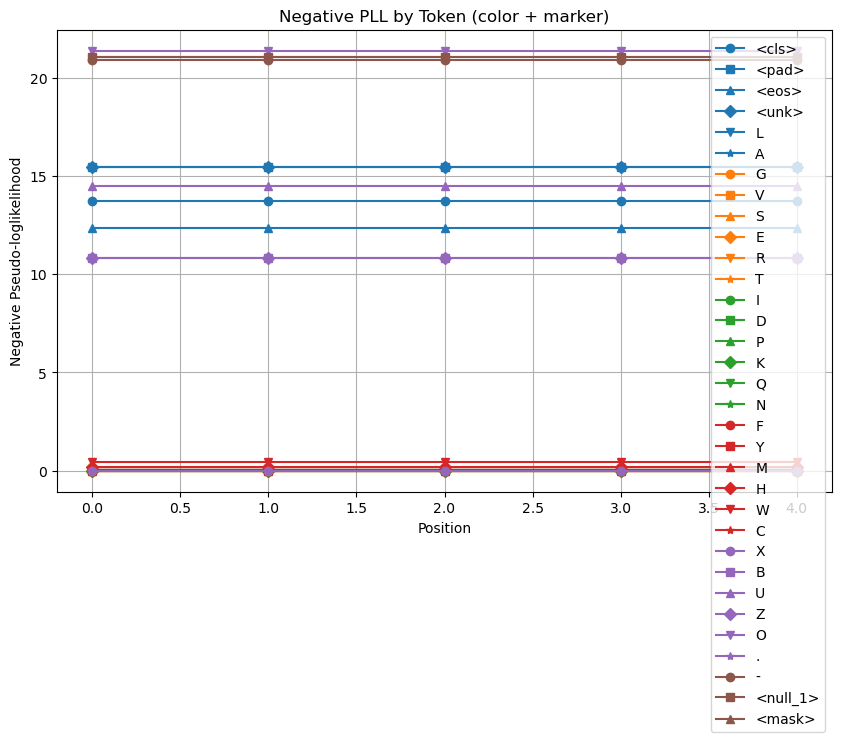

In [38]:
plt.figure(figsize=(10,6))

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']
markers = ['o', 's', '^', 'D', 'v', '*']

color_marker_cycle = itertools.cycle([(c, m) for c in colors for m in markers])

for key, vals in inputs_cp.items():
    color, marker = next(color_marker_cycle)
    positions = list(vals.keys())
    pll_values = [-v for v in vals.values()]  # <-- take negative here
    plt.plot(positions, pll_values, marker=marker, color=color, label=key, linestyle='-', linewidth=1.5)

plt.xlabel("Position")
plt.ylabel("Negative Pseudo-loglikelihood")
plt.title("Negative PLL by Token (color + marker)")
plt.legend()
plt.grid(True)
plt.show()

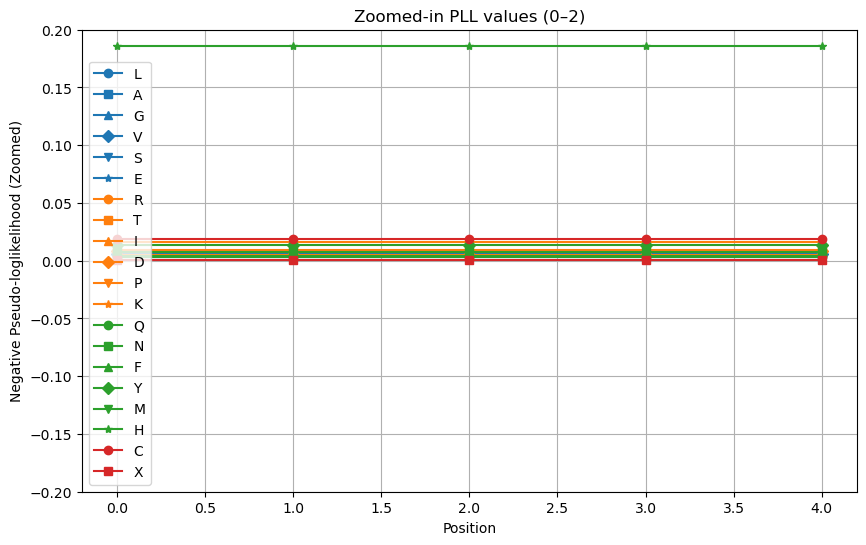

In [62]:
import matplotlib.pyplot as plt
import itertools

plt.figure(figsize=(10,6))

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']
markers = ['o', 's', '^', 'D', 'v', '*']
color_marker_cycle = itertools.cycle([(c, m) for c in colors for m in markers])

for key, vals in inputs_cp.items():
    # Take negative values
    neg_vals = {pos: -v for pos, v in vals.items()}
    # Filter for 0 <= value <= 2
    filtered_vals = {pos: v for pos, v in neg_vals.items() if 0 <= v <= 0.2}
    if not filtered_vals:
        continue  # skip tokens with no values in range
    
    color, marker = next(color_marker_cycle)
    positions = list(filtered_vals.keys())
    pll_values = list(filtered_vals.values())
    plt.plot(positions, pll_values, marker=marker, color=color, label=key, linestyle='-', linewidth=1.5)

plt.xlabel("Position")
plt.ylabel("Negative Pseudo-loglikelihood (Zoomed)")
plt.title("Zoomed-in PLL values (0–2)")
plt.legend()
plt.grid(True)
plt.ylim(-0.2, 0.2)
plt.show()


In [27]:

input_seq = 'PRSIRFTAEEGDLGFTLRGNAPVQVHFLDPYCSASVAG'

# Testing palindromes

In [154]:

input_seq = 'AAAAAAA'
input_seq = 'YYYYYYY'
pdz_2vsv = "PRSIRFTAEEGDLGFTLRGNAPVQVHFLDPYCSASVAGAREGDYIVSIQLVDCKWLTLSEVMKLLKSFGEDEIEMKVVSLL"
input_seq = pdz_2vsv
pdz_1gm1 = "KPGDTFEVELAKTDGSLGISVTGGVNTSVRHGGIYVKAIIPKGAAESDGRIHKGDRVLAVNGVSLEGATHKQAVETLRNTGQVVHLLLEKGQVP"
input_seq = pdz_1gm1
input_seq = 'TGAKALAKAGT'
input_seq = "LTIITL"
input_seq = "STPMLKSTPMLKSTPMLKSTPMLKSTPMLKSTPMLKSTPMLKSTPMLKSTPMLKSTPMLK"

In [155]:
#%%time
results_og = pll_all_cps(seq = input_seq, model = 'og')
results_cp = pll_all_cps(seq = input_seq, model ='cp')

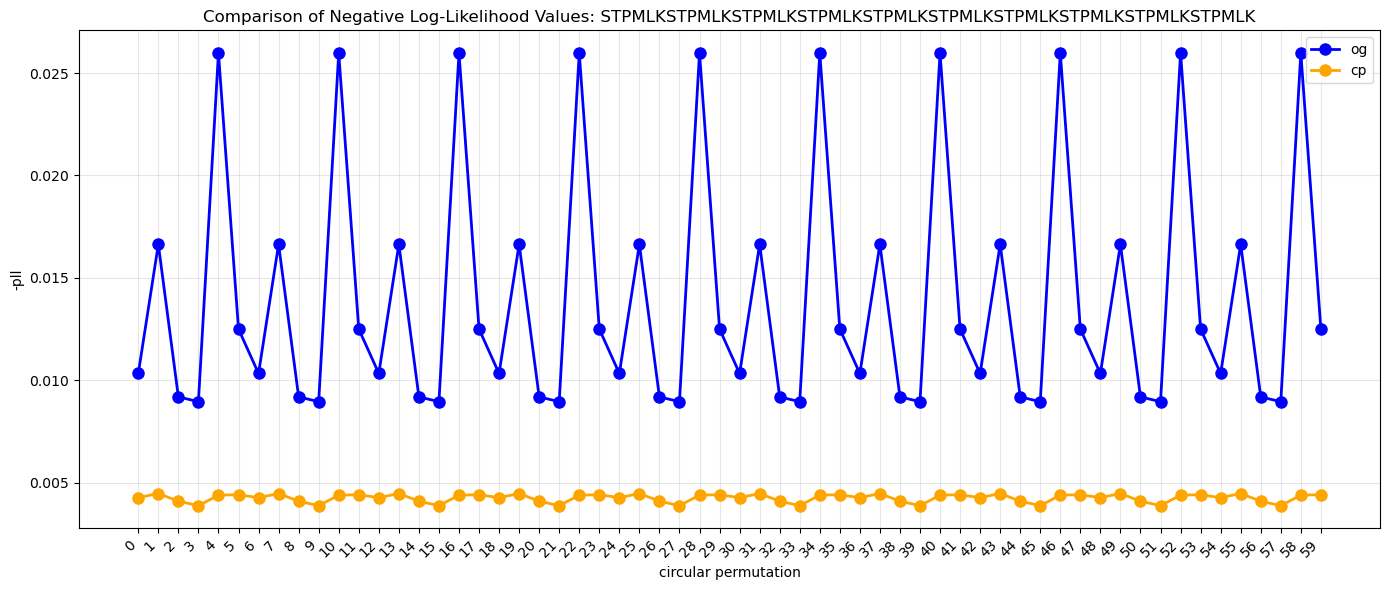

In [156]:
plot_pll(results_og, results_cp, "STPMLKSTPMLKSTPMLKSTPMLKSTPMLKSTPMLKSTPMLKSTPMLKSTPMLKSTPMLK")

In [ ]:
seq = 'PRSIRFTAEEGDLGFTLRGNAPVQVHFLDPYCSASVAGAREGDYIVSIQLVDCKWLTLSEVMKLLKSFGEDEIEMKVVSLL'
calculate_pll_single_seq(seq,cp=True)

In [ ]:
input_ids = inputs_tok['input_ids']
# Remove the start of sequence and end of sequence tokens
### Or include the start of sequence token if finetuning with <cls> as separator token?
### Removing start and end sequence tokens for now. 
sequence_length = input_ids.shape[1] - 2 
pll = 0
for pos in range(1, sequence_length + 1):
    # Create masked input for this position
    masked_input = input_ids.clone()
    # Mask a single position
    masked_input[0, pos] = tokenizer.mask_token_id  # Mask this position

    with torch.no_grad():
        # Don't need attn mask if no padding, don't need hidden states
        m_out = model_og(input_ids = masked_input, output_hidden_states=False)
        # Get logits for a position
        logits = m_out['logits'][0,pos]
        # Softmax the logits to get log probabilities of each token
        log_prob_pos = F.log_softmax(logits, dim = -1)

        # Make a zero vector and then one-hot encode the index corresponding to the token ID in input_ids[pos]
        one_hot_pos = torch.zeros(vocab_size, device=input_ids.device)
        token_id = input_ids[0,pos].item()
        one_hot_pos[token_id] = 1
        # calculate the pseudolikelihood for this position 
        pll_pos = (one_hot_pos * log_prob_pos).sum()
        pll += pll_pos.item()

In [ ]:
input_ids = inputs_tok['input_ids']
# Remove the start of sequence and end of sequence tokens
### Or include the start of sequence token if finetuning with <cls> as separator token?
### Removing start and end sequence tokens for now. 
sequence_length = input_ids.shape[1] - 2 
pll = 0
for pos in range(1, sequence_length + 1):
    # Create masked input for this position
    masked_input = input_ids.clone()
    # Mask a single position
    masked_input[0, pos] = tokenizer.mask_token_id  # Mask this position

    with torch.no_grad():
        # Don't need attn mask if no padding, don't need hidden states
        m_out = model_cp(input_ids = masked_input, output_hidden_states=False)
        # Get logits for a position
        logits = m_out['logits'][0,pos]
        # Softmax the logits to get log probabilities of each token
        log_prob_pos = F.log_softmax(logits, dim = -1)

        # Make a zero vector and then one-hot encode the index corresponding to the token ID in input_ids[pos]
        one_hot_pos = torch.zeros(vocab_size, device=input_ids.device)
        token_id = input_ids[0,pos].item()
        one_hot_pos[token_id] = 1
        # calculate the pseudolikelihood for this position 
        pll_pos = (one_hot_pos * log_prob_pos).sum()
        pll += pll_pos.item()

In [ ]:
pll

In [ ]:
# Get the vocabulary mapping
vocab = tokenizer.get_vocab()  # token -> id mapping
vocab

In [ ]:
# Check total vocabulary size
tokenizer

### Forward pass of input sequence through ESM

In [ ]:
with torch.no_grad():
    ## ** operator unpacks the dictionary into input arguments: input_ids and attention_mask
    ### Only need the input_ids argument if there's no padding, if there is padding then you need to include the attention mask so that it ignores padded positions during attention
    outputs_og = model_og(input_ids = inputs_tok['input_ids'], output_hidden_states=True)
    print(f'Generated ESM outputs with {outputs_og.keys()}')


In [ ]:
with torch.no_grad():
    ## ** operator unpacks the dictionary into input arguments: input_ids and attention_mask
    outputs_og = model_og(**inputs_tok, output_hidden_states=True)
    print(f'Generated ESM outputs with {outputs_og.keys()}')


### Mask each position

In [ ]:
print("Special token IDs:")
print(f"CLS: {tokenizer.cls_token_id}")
print(f"SEP: {tokenizer.sep_token_id}")
print(f"PAD: {tokenizer.pad_token_id}")
print(f"UNK: {tokenizer.unk_token_id}")
print(f"MASK: {tokenizer.mask_token_id}")

In [ ]:
# Per-residue embeddings (excluding special tokens)
# ESM2 adds <cls> at start and <eos> at end, so slice them out
# Extract embeddings
# Get the last hidden state (per-residue embeddings)
last_hidden_state = outputs_og.hidden_states[-1] 
last_hidden_state.shape
per_residue_embeddings = last_hidden_state[0, 1:-1, :]  # Shape: [protein_len, 640]

# Sequence-level embedding (1280-dim): Use <cls> token representation
sequence_embedding = last_hidden_state[:, 0, :]  # Shape: [batch_size, 640]

In [ ]:
def compute_pll_all_positions(sequence, tokenizer, model_outputs, model_name="model"):
    """
    Compute pseudologlikelihood for all positions in the sequence.
    
    Args:
        sequence: Original protein sequence
        tokenizer: ESM tokenizer
        model_outputs: Model outputs (last_hidden_state)
        model_name: Name for identification
    
    Returns:
        Dictionary with PLL metrics for all positions
    """
    device = model_outputs.device
    
    # Tokenize the sequence
    tokens = tokenizer(sequence, return_tensors='pt', padding=True, truncation=True)
    input_ids = tokens['input_ids'].to(device)
    
    # Get sequence length (excluding CLS and SEP tokens)
    sequence_length = input_ids.shape[1] - 2
    
    total_log_likelihood = 0.0
    position_scores = []
    
    # Process all positions (excluding CLS and SEP)
    for pos in range(1, sequence_length + 1):
        # Get the logits for this position
        logits = model_outputs[0, pos, :]  # Shape: [vocab_size]
        
        # Get the original token at this position
        original_token = input_ids[0, pos].item()
        
        # Compute log probabilities
        log_probs = F.log_softmax(logits, dim=-1)
        token_log_prob = log_probs[original_token].item()
        
        total_log_likelihood += token_log_prob
        
        position_scores.append({
            'position': pos - 1,  # Convert to 0-indexed
            'amino_acid': tokenizer.decode([original_token]),
            'log_prob': token_log_prob,
            'prob': np.exp(token_log_prob)
        })
    
    # Compute metrics
    avg_log_likelihood = total_log_likelihood / sequence_length
    perplexity = np.exp(-avg_log_likelihood)
    
    return {
        'sequence': sequence,
        'model': model_name,
        'total_log_likelihood': total_log_likelihood,
        'avg_log_likelihood': avg_log_likelihood,
        'perplexity': perplexity,
        'n_positions_evaluated': sequence_length,
        'position_scores': position_scores
    }


In [ ]:
def compare_models_pll(sequence, tokenizer, model1_outputs, model2_outputs, 
                      model1_name="Model 1", model2_name="Model 2", all_positions=True):
    """
    Compare pseudologlikelihood between two models.
    
    Args:
        sequence: Protein sequence
        tokenizer: ESM tokenizer
        model1_outputs: Outputs from first model
        model2_outputs: Outputs from second model
        model1_name: Name of first model
        model2_name: Name of second model
        all_positions: Whether to evaluate all positions or sample
    
    Returns:
        Comparison results
    """
    
    if all_positions:
        pll1 = compute_pll_all_positions(sequence, tokenizer, model1_outputs, model1_name)
        pll2 = compute_pll_all_positions(sequence, tokenizer, model2_outputs, model2_name)
    else:
        # Use same random seed for fair comparison
        np.random.seed(42)
        pll1 = compute_pseudologlikelihood_from_outputs(sequence, tokenizer, model1_outputs, model_name=model1_name)
        np.random.seed(42)
        pll2 = compute_pseudologlikelihood_from_outputs(sequence, tokenizer, model2_outputs, model_name=model2_name)
    
    # Print comparison
    print(f"Pseudologlikelihood Comparison:")
    print(f"Sequence: {sequence[:50]}{'...' if len(sequence) > 50 else ''}")
    print(f"Sequence length: {len(sequence)}")
    print("-" * 60)
    
    print(f"{model1_name}:")
    print(f"  Average log-likelihood: {pll1['avg_log_likelihood']:.4f}")
    print(f"  Perplexity: {pll1['perplexity']:.4f}")
    print(f"  Total log-likelihood: {pll1['total_log_likelihood']:.4f}")
    
    print(f"\n{model2_name}:")
    print(f"  Average log-likelihood: {pll2['avg_log_likelihood']:.4f}")
    print(f"  Perplexity: {pll2['perplexity']:.4f}")
    print(f"  Total log-likelihood: {pll2['total_log_likelihood']:.4f}")
    
    # Compute differences
    ll_diff = pll1['avg_log_likelihood'] - pll2['avg_log_likelihood']
    perp_diff = pll1['perplexity'] - pll2['perplexity']
    
    print(f"\nDifference ({model1_name} - {model2_name}):")
    print(f"  Avg log-likelihood: {ll_diff:+.4f}")
    print(f"  Perplexity: {perp_diff:+.4f}")
    
    if ll_diff > 0:
        print(f"  {model1_name} has HIGHER pseudologlikelihood (better)")
    else:
        print(f"  {model2_name} has HIGHER pseudologlikelihood (better)")
    
    return pll1, pll2

def plot_position_comparison(pll1, pll2):
    """Plot position-by-position comparison."""
    
    # Extract position data
    pos1 = [p['position'] for p in pll1['position_scores']]
    logprobs1 = [p['log_prob'] for p in pll1['position_scores']]
    
    pos2 = [p['position'] for p in pll2['position_scores']]
    logprobs2 = [p['log_prob'] for p in pll2['position_scores']]
    
    # Create plots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    # Position-wise log probabilities
    ax1.plot(pos1, logprobs1, 'o-', label=pll1['model'], alpha=0.7, markersize=4)
    ax1.plot(pos2, logprobs2, 's-', label=pll2['model'], alpha=0.7, markersize=4)
    ax1.set_xlabel('Position')
    ax1.set_ylabel('Log Probability')
    ax1.set_title('Position-wise Log Probabilities')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Difference plot
    if len(pos1) == len(pos2):
        diff = np.array(logprobs1) - np.array(logprobs2)
        ax2.plot(pos1, diff, 'ro-', alpha=0.7, markersize=4)
        ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        ax2.set_xlabel('Position')
        ax2.set_ylabel(f'Log Prob Difference\n({pll1["model"]} - {pll2["model"]})')
        ax2.set_title('Position-wise Difference in Log Probabilities')
        ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Example usage function
def example_comparison(sequence, tokenizer, model1_outputs, model2_outputs):
    """
    Example of how to run the comparison.
    
    Args:
        sequence: Your test protein sequence
        tokenizer: ESM tokenizer
        model1_outputs: Outputs from your fine-tuned model (last_hidden_state)
        model2_outputs: Outputs from the baseline model (last_hidden_state)
    """
    
    # Compare models
    pll_finetuned, pll_baseline = compare_models_pll(
        sequence=sequence,
        tokenizer=tokenizer,
        model1_outputs=model1_outputs,
        model2_outputs=model2_outputs,
        model1_name="Fine-tuned (Circular Perm)",
        model2_name="Baseline ESM2",
        all_positions=True  # Set to False for sampling approach
    )
    
    # Plot comparison
    plot_position_comparison(pll_finetuned, pll_baseline)
    
    return pll_finetuned, pll_baseline

# If you have your outputs ready, use like this:
# pll_finetuned, pll_baseline = example_comparison(
#     sequence="YOUR_SEQUENCE",
#     tokenizer=tokenizer,
#     model1_outputs=finetuned_outputs.last_hidden_state,
#     model2_outputs=baseline_outputs.last_hidden_state
# )

In [ ]:
outputs_og.logits

In [ ]:
example_comparison(test_sequence,tokenizer,outputs_og.logits,outputs_cp.logits)